In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [12]:
data= pd.read_csv(r"/Users/zihad/Desktop/Project/Fallstadion 1/pro 3/bike_rental_data.csv")
na_data=data.isna().sum()
print(f"Missing values in dataset:\n",na_data)
data.head()

Missing values in dataset:
 Unnamed: 0    0
dteday        0
mnth          0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


,Unnamed: 0,dteday,mnth,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,2011-01-01,1,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,2,2011-01-02,1,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,3,2011-01-03,1,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,4,2011-01-04,1,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,5,2011-01-05,1,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


Along with the associated weather
and seasonal data, the original dataset includes the hourly and daily count of rental
bikes in the Capital bikeshare system from 2011 to 2012. A small extraction of the
whole dataset is used for this report where there are nine variables and 731 observations
with no missing values. These include the cnt as the dependent variable and eight
independent variable (mnth, weekday, workingday, weather, temp, atemp, hum,
and windspeed)(Fanaee-T, 2013).
The target variable is the total number of rentals that occurred on the corresponding
day, denoted by cnt is a continuous variable. The mnth variable refers to the month
of the year, encoded as an integer from 1 to 12, where 1 corresponds to January, 2 to
February, and so on. The weekday variable represents the day of the week and is encoded
as an integer from 0 to 6. Here, 0 corresponds to Sunday, 1 to Monday, and so on. The
workingday is a binary dummy variable that indicates whether the day was a working
day or not. A value of 1 means that the day was neither a weekend nor a holiday, while
a value of 0 represents otherwise. The weathersit variable is a categorical feature that
describes the weather situation on the given day. It is encoded as 1 for clear weather
with few clouds, 2 for misty or cloudy conditions, and 3 for light rain, heavy rain, or
snow. The temp variable measures the temperature in Celsius, normalized between 0
and 1. Similarly, the atemp variable captures the "feels-like" temperature, which is the
perceived temperature based on factors such as wind or humidity. This is also normalized
between 0 and 1. The hum variable represents the humidity level, normalized between 0
and 1. Lastly, the windspeed variable describes the wind speed in meters per second,
standardized between 0 and 1.

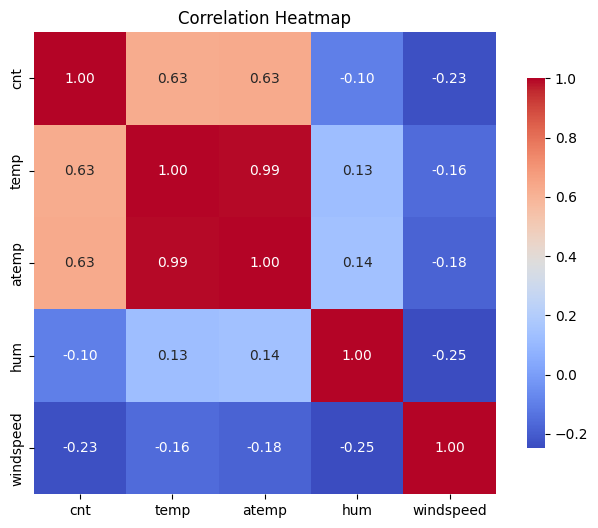

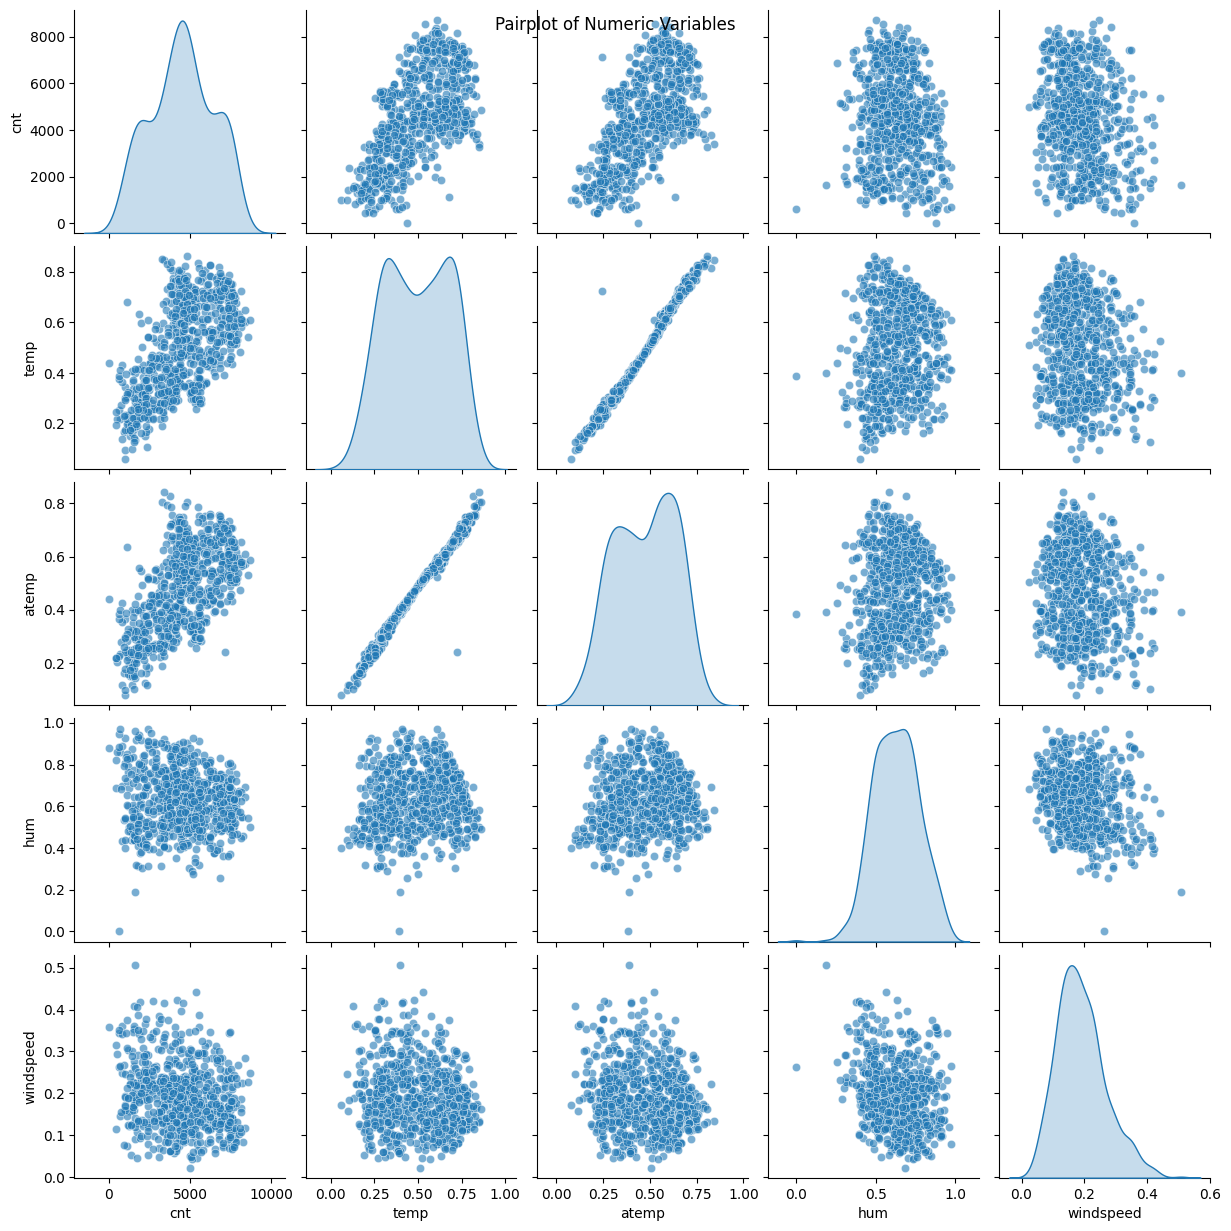

In [13]:
# Select numeric columns for correlation
numeric_cols = ['cnt', 'temp', 'atemp', 'hum', 'windspeed']

# Compute the correlation matrix
correlation_matrix = data[numeric_cols].corr()

# Create the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap")
plt.show()

# Pairplot for detailed relationships
sns.pairplot(data[numeric_cols], diag_kind='kde', kind='scatter', plot_kws={'alpha':0.6})
plt.suptitle("Pairplot of Numeric Variables")
plt.show()

The correlation heatmap reveals how strongly correlated each variable is with the oth-
ers. For example, the variable cnt, representing the number of bike rentals, is positively
correlated with both temp and atemp (both around 0.63). This suggests that higher tem-
peratures are associated with an increase in bike rentals, likely because warmer weather
encourages outdoor activities. Interestingly, temp and atemp themselves are almost per-
fectly correlated (0.99), indicating they capture very similar information—likely redun-
dancy. This relationship is addressed in model building to prevent multicollinearity. Con-
versely, hum and windspeed show weak negative correlations with cnt (-0.10 and -0.23,
respectively), suggesting that higher humidity and windspeed may slightly discourage
bike usage.
Moving on to the pairplot, it further visualizes these relationships
through scatterplots and histograms. The scatterplots confirm the positive association
betweencnt andtemp/atemp, showingupwardtrendsastemperatureincreases. However,
thereissomescatteraroundthetrendline,indicatingvariabilitythatmaynotbeperfectly
captured by a linear model. To furthur check this out, there is figure 4 which is a
scatterplot of cnt and temp on page 14. For hum and windspeed, the scatterplots display
no clear trend with cnt, reinforcing the weaker correlations observed earlier.
From figure 3 on page 14, categorical variable’s distribution is showed in bar graph. The
mnth variable shows an almost uniform distribution of observations across all 12 months.
This suggests consistency throughout the year, and no significant month stands out. The
7
workingday variable, a binary indicator, reveals a significant imbalance between working
days (1) and non-working days (0). From weathersit, the predominance of Category 1
indicates that favorable weather conditions are more common, which could positively
influence the bike rental count.

/var/folders/pp/r75z7t0s7pg6n8_s3dh22qrw0000gn/T/ipykernel_10704/3604044329.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=var, palette='viridis')


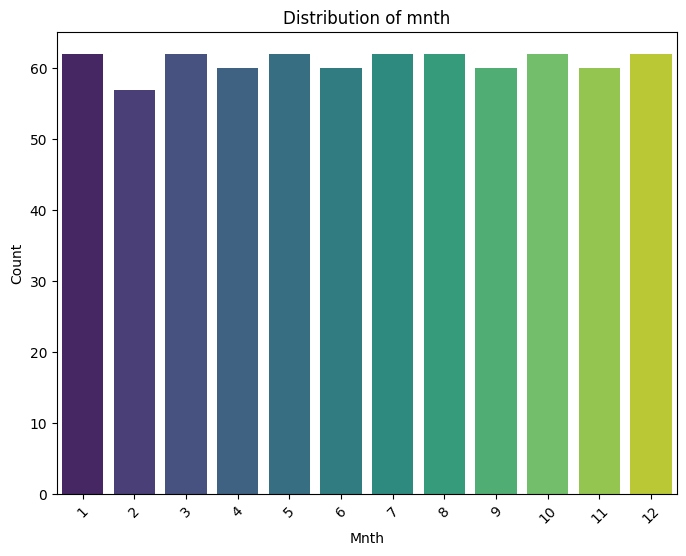

/var/folders/pp/r75z7t0s7pg6n8_s3dh22qrw0000gn/T/ipykernel_10704/3604044329.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=var, palette='viridis')


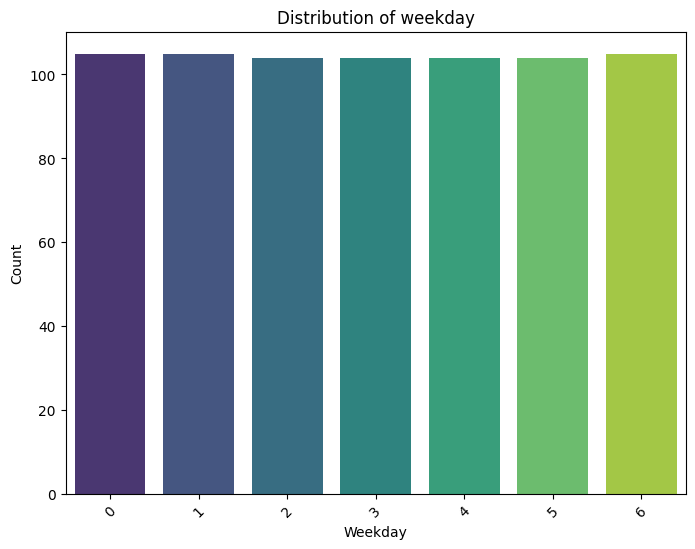

/var/folders/pp/r75z7t0s7pg6n8_s3dh22qrw0000gn/T/ipykernel_10704/3604044329.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=var, palette='viridis')


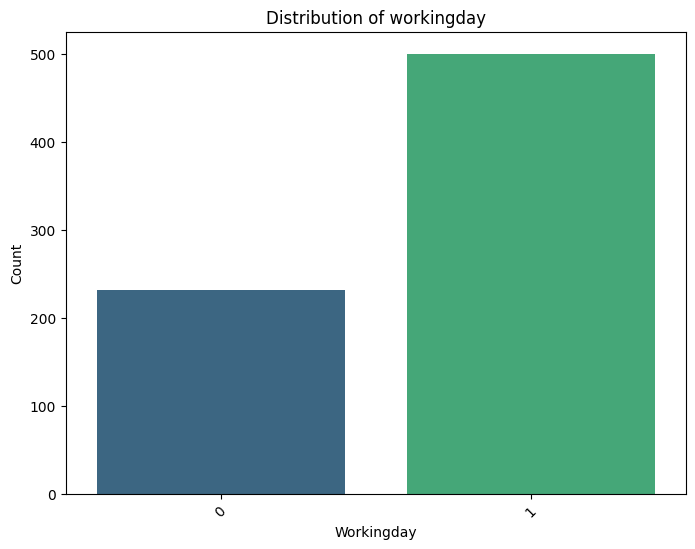

/var/folders/pp/r75z7t0s7pg6n8_s3dh22qrw0000gn/T/ipykernel_10704/3604044329.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=var, palette='viridis')


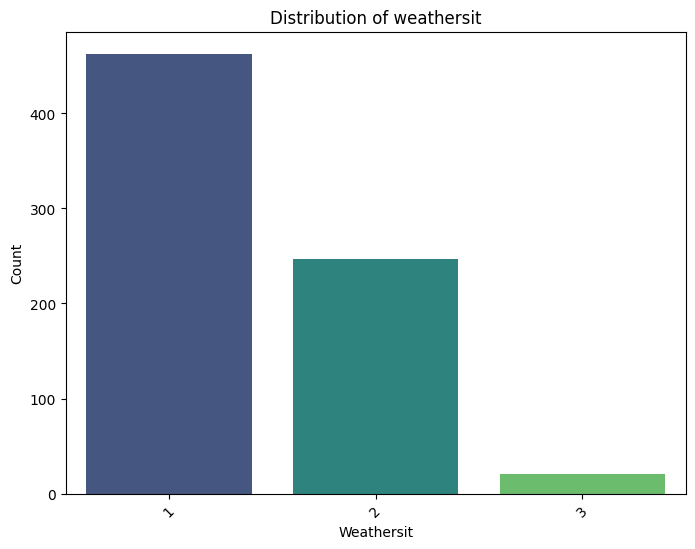

In [14]:
# List of categorical variables
categorical_vars = ['mnth', 'weekday', 'workingday', 'weathersit']

# Create bar charts for each categorical variable
for var in categorical_vars:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=data, x=var, palette='viridis')
    plt.title(f"Distribution of {var}")
    plt.xlabel(var.capitalize())
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

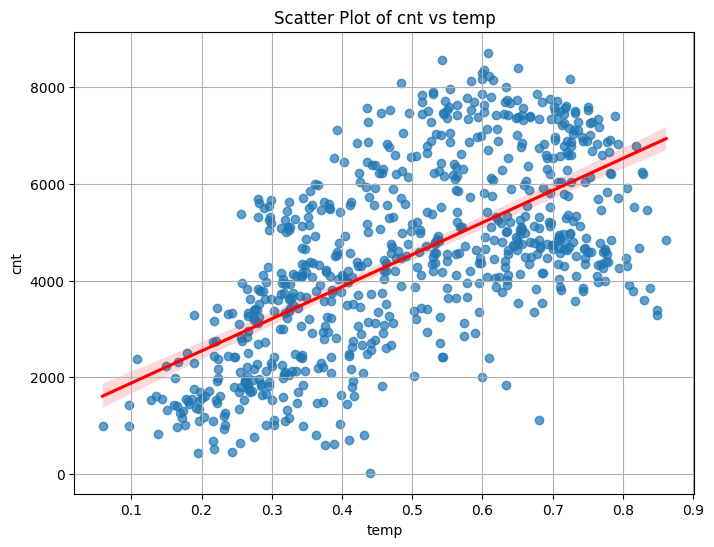

In [15]:
# Scatter plot between cnt and temp
plt.figure(figsize=(8, 6))
sns.regplot(x=data['temp'], y=data['cnt'], scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'})
plt.title('Scatter Plot of cnt vs temp')
plt.xlabel('temp')
plt.ylabel('cnt')
plt.grid(True)
plt.show()

In [16]:
# Drop non-numeric columns 
data = data.drop(columns=['dteday', 'Unnamed: 0'], errors='ignore')

# Prepare the feature matrix (X) and target variable (y)
X = data.drop(columns=['cnt'])
y = data['cnt']
# Add polynomial terms for 'temp' (quadratic and cubic)
poly = PolynomialFeatures(degree=4, include_bias=False)
temp_poly = poly.fit_transform(data[['temp']])
temp_poly_df = pd.DataFrame(temp_poly, columns=['temp', 'temp^2', 'temp^3','temp^4'])

# Drop original 'temp' and replace with polynomial terms
X = X.drop(columns=['temp']).reset_index(drop=True)
X = pd.concat([X, temp_poly_df], axis=1)
# Add a constant to the model (for intercept)
X = sm.add_constant(X)

# Fit the OLS regression model
model = sm.OLS(y, X).fit()
# Print the summary of the regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     100.9
Date:                Tue, 31 Mar 2026   Prob (F-statistic):          1.15e-137
Time:                        18:18:16   Log-Likelihood:                -6228.5
No. Observations:                 731   AIC:                         1.248e+04
Df Residuals:                     719   BIC:                         1.254e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4277.2195   1247.528      3.429      0.0

Using backward elimination as stepwise regression, a suitable model with smallest BIC
is chosen. The results reflect a refined Least Squares regression model after backward
elimination.

In [17]:
# Backward elimination based on BIC
def backward_elimination(X, y):
    model = sm.OLS(y, X).fit()
    bic = model.bic
    while True:
        # Fit the model and calculate BIC for all variables
        pvalues = model.pvalues.iloc[1:]  # Exclude intercept
        max_pval = pvalues.max()  # Find the predictor with the highest p-value
        
        if max_pval > 0.05:  # Set significance threshold
            excluded_feature = pvalues.idxmax()  # Get the variable with the highest p-value
            X = X.drop(columns=[excluded_feature])  # Remove the least significant variable
            
            # Refit the model
            model = sm.OLS(y, X).fit()
            new_bic = model.bic
            
            # Stop if BIC increases
            if new_bic > bic:
                break
            bic = new_bic
        else:
            break
    return model

# Run backward elimination
final_model = backward_elimination(X, y)

# Print the final model summary
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     158.7
Date:                Tue, 31 Mar 2026   Prob (F-statistic):          1.71e-141
Time:                        18:18:20   Log-Likelihood:                -6229.5
No. Observations:                 731   AIC:                         1.248e+04
Df Residuals:                     723   BIC:                         1.251e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3727.1222    297.047     12.547      0.0

The model explains 60.6% of the variation in bike rental counts (R2 = 0.606), accounting
for the number of predictors. From table, it is evident that for mnth, each additional
month corresponds to an increase of approximately 71 rentals, reflecting a seasonal up-
ward trend in bike rentals. For weathersit, worse weather conditions significantly reduce
8
bike rentals, with a decrease of 455 counts. For windspeed, high wind speed strongly re-
duces bike rentals by about 4763 counts.The analysis in Table highlights the significance
of temp2 and temp3, which were not significant in the initial regression model. The posi-
tive coefficient of temp2 indicates that bike rentals increase with moderate temperatures,
suggesting a quadratic relationship. Conversely, the negative coefficient of temp3 points
to diminishing returns at higher temperature levels. These findings collectively suggest
an "inverted U-shaped" relationship, where bike rentals peak at moderate temperatures
and decline when temperatures become excessively high or low, likely due to decreased
demand under extreme weather conditions. This provides evidence supporting the exis-
tence of a non-linear relationship between temperature and bike rentals (an upward trend
initially but peaking and then declining at extreme temperatures). The absence of zero
in any of the confidence intervals indicates that all retained predictors are significant.

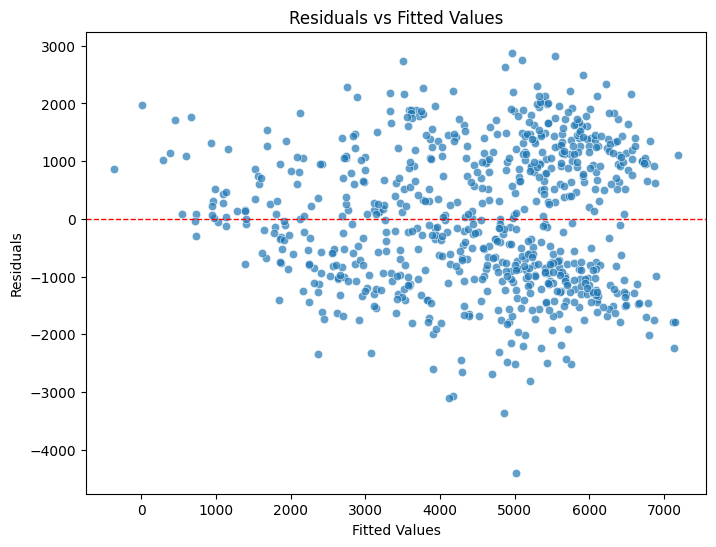

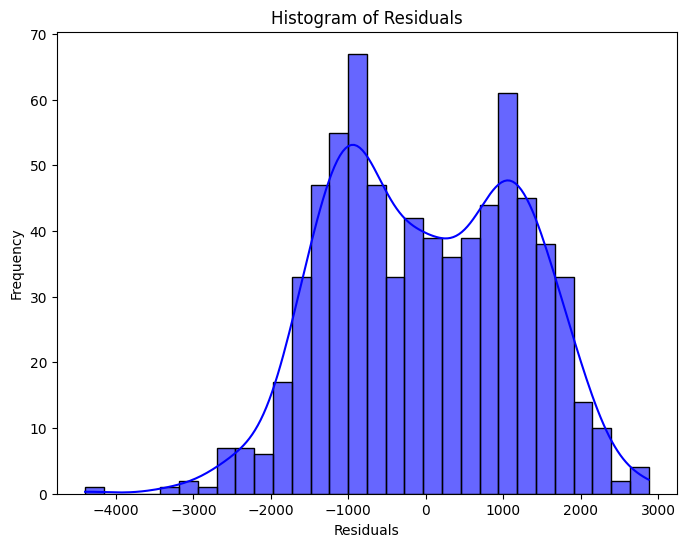

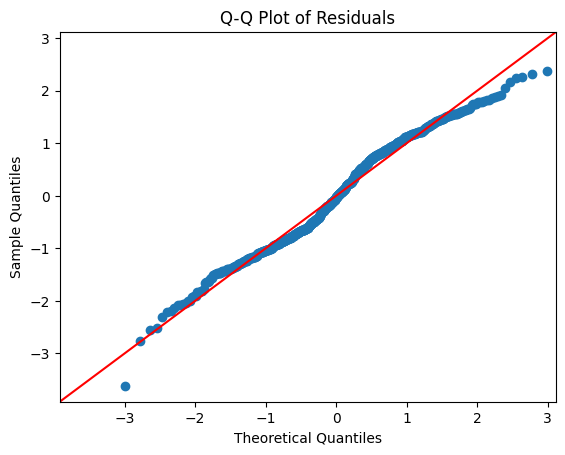

      Feature        VIF
0       const  43.170355
1        mnth   1.134938
2     weekday   1.010361
3  weathersit   1.729158
4         hum   1.953945
5   windspeed   1.177096
6      temp^2  58.850647
7      temp^3  58.184566


In [18]:
# Final model predictors
selected_features = final_model.model.exog_names  # Includes 'const'
selected_features = [f for f in selected_features if f != 'const']

# Residual plots
fitted_values = final_model.fittedvalues
residuals = final_model.resid

# 1. Residual vs. Fitted Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# 2. Histogram of Residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30, color='blue', alpha=0.6)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# 3. Q-Q Plot
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

# 4. Multicollinearity Check: VIF
X_selected = sm.add_constant(X[selected_features])  # Subset of X used in the final model
vif_data = pd.DataFrame({
    'Feature': X_selected.columns,
    'VIF': [variance_inflation_factor(X_selected.values, i) for i in range(X_selected.shape[1])]
})
print(vif_data)


To check multicollinearity, from table , mnth, weekday, weathersit, hum and windspeed
all have VIF value around 1 suggesting low or moderate multicollinearity. temp2 and
temp3 have very high VIF values, indicates severe multicollinearity between the polyno-
mial temperature terms. But polynomial terms are inherently highly correlated because
they are powers of the same base variable (temp). This is expected when including
higher-order terms in regression models